In [4]:
import matplotlib.pyplot as plt
import numpy as np
import graph_style as gs
from scipy.optimize import curve_fit
from matplotlib.ticker import FormatStrFormatter
import fig_helper as fh

gs.set_graph_style(1.0)


In [6]:
date = "2025-05-03"
rid_det = 23502  # detune LS 3.5 kHz
rid_dur = 23503  # duration
rid_tb = 23501  # LS 4 kHz

det_dict = fh.load_data(rid_det, date)
dur_dict = fh.load_data(rid_dur, date)
tb_dict = fh.load_data(rid_tb, date)

In [37]:

def thermal_split(x, W):
    """
    nbar is initial thermal phonon number
    W is the SDF Rabi frequency
    """
    nbar = 0.0#3  # measured temperature
    a = W * x / 2
    return 1 / 2 * (1 + np.exp(-4 * (nbar + 1 / 2) * a**2))


def detune_sdf(x, W):
    """
    x is detuning in radians/s
    nbar is initial thermal phonon number
    W is the SDF Rabi frequency in radians/s
    """
    nbar = 0.0#3  # measured temperature
    t = 100e-6
    a = W * np.sinc(x * t / (2 * np.pi)) * t / 2  # numpy normalised sinc
    return 1 / 2 * (1 + np.exp(-4 * (nbar + 1 / 2) * a**2))




# for x in det_dict["datasets"].keys():
# print(x)

duration = np.array(dur_dict["datasets"][f"ndscan.rid_{rid_dur}.points.axis_0"])
pop_dur = np.array(
    dur_dict["datasets"][
        f"ndscan.rid_{rid_dur}.points.channel_measurement_camera_readout_p"
    ]
)
pop_err_dur = np.array(
    dur_dict["datasets"][
        f"ndscan.rid_{rid_dur}.points.channel_measurement_camera_readout_p_err"
    ]
)
argsort_dur = np.argsort(duration)
duration = duration[argsort_dur]
pop_dur = pop_dur[argsort_dur]
pop_err_dur = pop_err_dur[argsort_dur]
#----------
detuning = np.array(det_dict["datasets"][f"ndscan.rid_{rid_det}.points.axis_0"])
pop_det = np.array(
    det_dict["datasets"][
        f"ndscan.rid_{rid_det}.points.channel_measurement_camera_readout_p"
    ]
)
pop_err_det = np.array(
    det_dict["datasets"][
        f"ndscan.rid_{rid_det}.points.channel_measurement_camera_readout_p_err"
    ]
)
total_pts = 50
detuning = detuning[:total_pts]
pop_det = pop_det[:total_pts]
pop_err_det = pop_err_det[:total_pts]

argsort_dur = np.argsort(detuning)
detuning = detuning[argsort_dur]
pop_det = pop_det[argsort_dur]
pop_err_det = pop_err_det[argsort_dur]

#-----------
detuning_tb = np.array(tb_dict["datasets"][f"ndscan.rid_{rid_tb}.points.axis_0"])
pop_tb = np.array(
    tb_dict["datasets"][
        f"ndscan.rid_{rid_tb}.points.channel_measurement_camera_readout_p"
    ]
)
pop_err_tb = np.array(
    tb_dict["datasets"][
        f"ndscan.rid_{rid_tb}.points.channel_measurement_camera_readout_p_err"
    ]
)
detuning_tb = detuning_tb[:total_pts]
pop_tb = pop_tb[:total_pts]
pop_err_tb = pop_err_tb[:total_pts]

# Fit duration data
p_fit, p_cov = curve_fit(
    thermal_split,
    duration,
    pop_dur,
    p0=[2 * np.pi * 6.37e3],
    sigma=pop_err_dur,
    bounds=([2 * np.pi * 0e3], [2 * np.pi * 100e3]),
)

Wsdf = p_fit[0] / 1000
p_errs = np.sqrt(np.diag(p_cov))
Wsdf_err = p_errs[0] / 1000
print(f"Omega_sdf: 2pi {Wsdf / (2 * np.pi):.3f} +/- {Wsdf_err / (2 * np.pi):.3f} kHz")

# Fit detuning data
p_fit_det, p_cov_det = curve_fit(
    detune_sdf,
    detuning * 2 * np.pi,
    pop_det,
    p0=[2 * np.pi * 6.37e3],
    sigma=pop_err_det,
    bounds=([2 * np.pi * 0e3], [2 * np.pi * 100e3]),
)
Wsdf_det = p_fit_det[0] / 1000
p_errs_det = np.sqrt(np.diag(p_cov_det))
Wsdf_det_err = p_errs_det[0] / 1000
print(
    f"Omega_sdf_det: 2pi {Wsdf_det / (2 * np.pi):.3f} +/- {Wsdf_det_err / (2 * np.pi):.3f} kHz"
)


Omega_sdf: 2pi 6.751 +/- 0.216 kHz
Omega_sdf_det: 2pi 6.346 +/- 0.214 kHz


<>:95: SyntaxWarning: invalid escape sequence '\O'
<>:95: SyntaxWarning: invalid escape sequence '\O'
C:\Users\webbd\AppData\Local\Temp\ipykernel_37080\2457087953.py:95: SyntaxWarning: invalid escape sequence '\O'
  "$\Omega_{\\rm SDF}$ = 2$\pi \\times $ "


$\Omega_{\rm SDF}$ = 2$\pi \times $ 6.8 (2) kHz


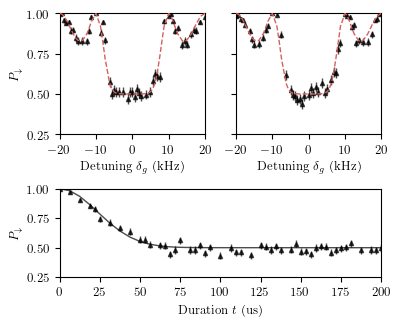

In [38]:
# creating grid for subplots
fig = plt.figure()

fig_width = gs.get_fig_width()*3/4
fig_height =  fig_width*4/5
fig.set_size_inches(fig_width, fig_height)

ax0 = plt.subplot2grid(shape=(100, 100), loc=(0, 5), colspan=43, rowspan=45)
ax1 = plt.subplot2grid(shape=(100, 100), loc=(0, 57), colspan=43, rowspan=45)
ax2 = plt.subplot2grid(shape=(100, 100), loc=(65, 5), colspan=95, rowspan=33)

# share y ticks
ax0.sharey(ax1)
ax1.tick_params(labelleft=False)

ax0.errorbar(
    detuning / 1000,
    pop_det,
    yerr=pop_err_det,
    fmt="^",
    label="Detuning",
    alpha=gs.get_alpha(),
    elinewidth=1.0,
    color="k",
)
ax0.set_xlabel("Detuning $\\delta_g$ (kHz)")
ax0.set_xlim(-20, 20)
ax0.set_xticks(
    np.arange(-20, 21, 10),
)
ax0.set_ylabel("$P_\\downarrow$")
ax0.set_ylim(0.25, 1.0)
ax0.set_yticks(
    np.arange(0.25, 1.25, 0.25),
)
ax1.errorbar(
    detuning_tb / 1000,
    pop_tb,
    yerr=pop_err_tb,
    fmt="^",
    label="Detuning Tone Balance",
    alpha=gs.get_alpha(),
    elinewidth=1.0,
    color="k",
)
ax0.plot(
    detuning / 1000,
    detune_sdf(detuning * 2 * np.pi, *p_fit),
    label="Fit",
    ls="--",
    zorder=10,
    color=gs.get_color(2)
)
ax1.plot(
    detuning / 1000,
    detune_sdf(detuning * 2 * np.pi, *p_fit),
    label="Fit",
    ls="--",
    zorder=10,
    color=gs.get_color(2)
)
ax1.set_xlabel("Detuning $\\delta_g$ (kHz)")
ax1.set_xlim(-20, 20)
ax1.set_xticks(
    np.arange(-20, 21, 10),
)

ax2.errorbar(
    duration * 1e6,
    pop_dur,
    yerr=pop_err_dur,
    fmt="^",
    label="Duration",
    alpha=gs.get_alpha(),
    elinewidth=1.0,
    color="k",
)
ax2.set_ylim(0.25, 1.0)
ax2.set_yticks(
    np.arange(0.25, 1.25, 0.25),
)
ax2.set_xlim(0, 200)
ax2.set_xlabel("Duration $t$ (us)")
ax2.set_ylabel("$P_\\downarrow$")
ax2.plot(
    duration * 1e6,
    thermal_split(duration, *p_fit),
    label="Fit",
    alpha=gs.get_alpha(),
    color="k",
    ls="-"
)

textstr = (
    "$\Omega_{\\rm SDF}$ = 2$\pi \\times $ "
    + f"{Wsdf / (2 * np.pi):.1f} ({10*Wsdf_err / (2 * np.pi):.0f}) kHz"
)
print(textstr)

# ax2.text(
#     0.95,
#     0.95,
#     textstr,
#     transform=ax2.transAxes,
#     verticalalignment="top",
#     horizontalalignment="right",
#     fontsize=12,
# )
for ax in [ax0, ax1, ax2]:
    ax.grid(None)
f_name = "..\\..\\pdf_figure\\ch4\\sdf_py.pdf"
# plt.savefig(f_name, bbox_inches="tight", dpi=300)